# Phase 1: Exploratory Data Analysis (EDA)
**Project 05 — Insurance Premium Prediction**

The goal of this notebook is to understand the distributions of our features and uncover the relationships between customer demographics, lifestyle choices (like smoking), and their insurance charges.

In [23]:
import os
import pandas as pd

# Check if we are inside the 'notebooks' directory
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

print(f"Current Working Directory: {os.getcwd()}")

Current Working Directory: C:\Users\hasan\Documents\Python\ml25\project-05-insurance-premium-prediction


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic styling for the plots
sns.set_theme(style="whitegrid", palette="muted")

# Load the dataset (adjust path if necessary)
df = pd.read_csv('data/raw/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Univariate Analysis
Let's look at the distribution of our continuous variables: Age, BMI, and Charges.

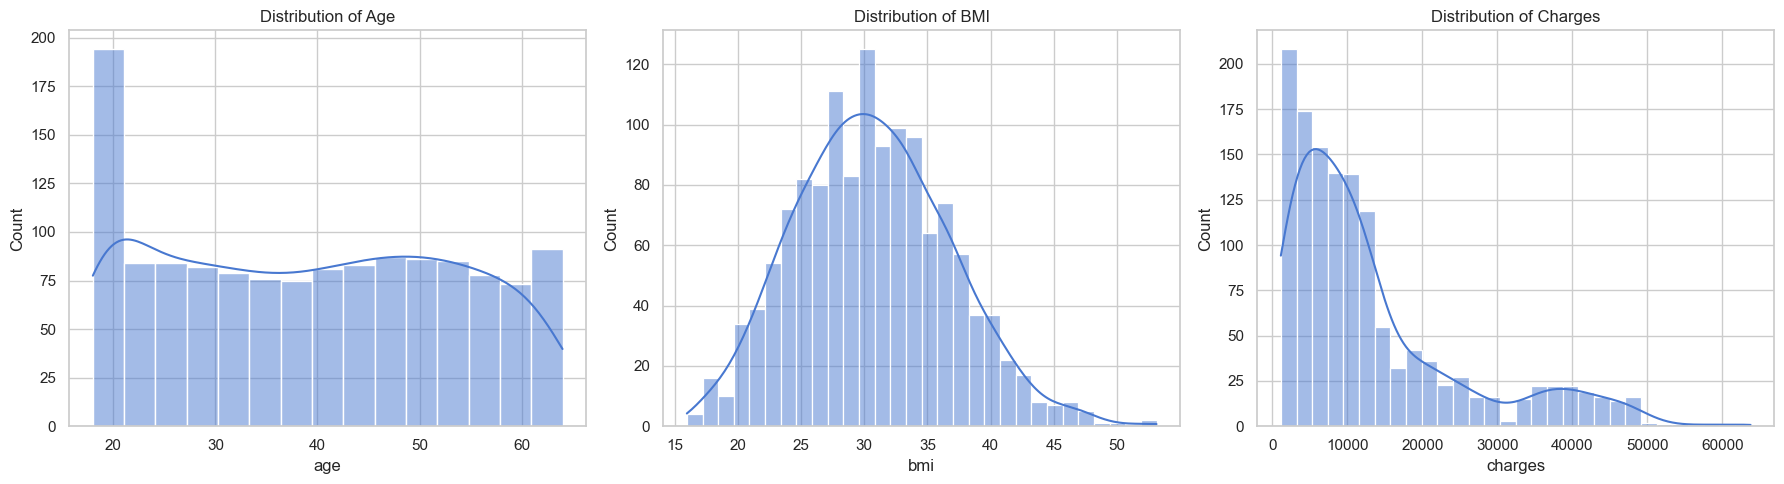

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['age'], bins=15, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')

sns.histplot(df['bmi'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of BMI')

sns.histplot(df['charges'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Charges')

plt.tight_layout()
plt.show()

*Insight:* `charges` is highly right-skewed. Most people have lower medical costs, but a tail of individuals has extremely high costs. `bmi` is normally distributed.

## 2. Categorical Analysis
Let's see the breakdown of categorical features: Sex, Smoker, Region, and Children.

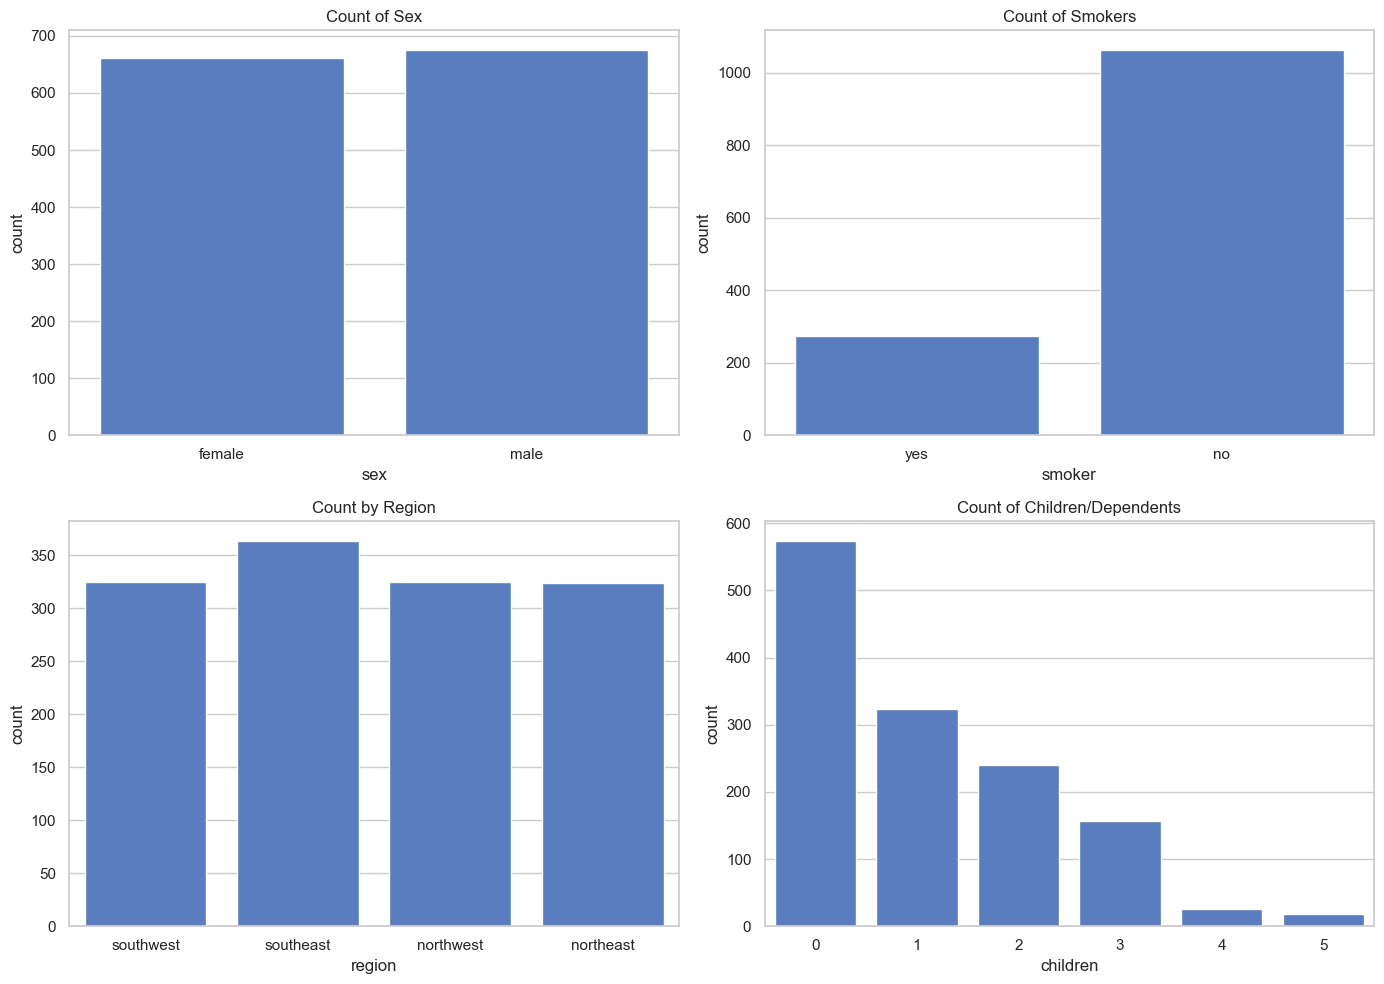

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='sex', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Count of Sex')

sns.countplot(x='smoker', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Count of Smokers')

sns.countplot(x='region', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Count by Region')

sns.countplot(x='children', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Count of Children/Dependents')

plt.tight_layout()
plt.show()

## 3. Bivariate Analysis (The "Aha!" Moment)
Let's investigate what drives those extremely high charges we saw in the distribution plot. We will look at BMI vs. Charges, separated by Smoker status.

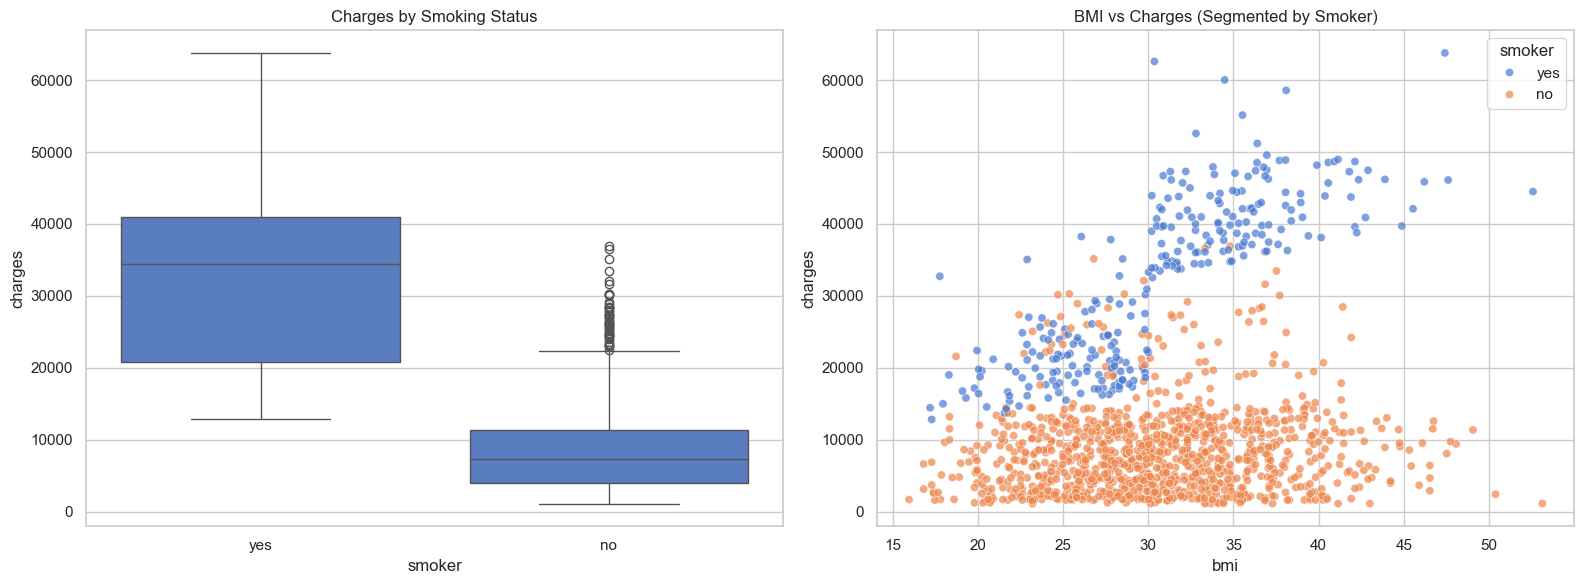

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot of Smoker vs Charges
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0])
axes[0].set_title('Charges by Smoking Status')

# Scatterplot of BMI vs Charges, colored by Smoker
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.7, ax=axes[1])
axes[1].set_title('BMI vs Charges (Segmented by Smoker)')

plt.tight_layout()
plt.show()

*Crucial Insight:* Smoking is the biggest driver of high insurance charges. Furthermore, the scatterplot reveals compounding risk: if a customer is a smoker *and* has a high BMI (above 30), their charges skyrocket. This justifies our plan to create `bmi_band` and `age_band` features in the next phase.

## 4. Correlation Matrix
Finally, let's look at the correlation between our numerical variables.

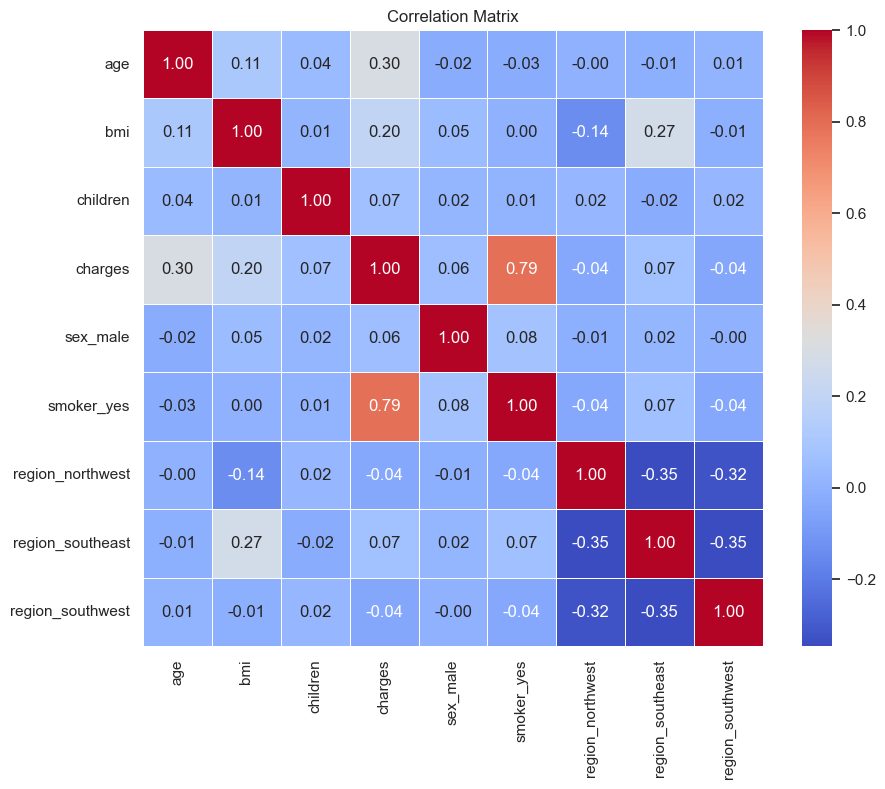

In [28]:
# Convert categorical features temporarily for a full correlation matrix
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()